# OLS Regression Example 

This notebook shows how to use regression in Python. We will use the `statsmodels` library to fit an OLS regression model to some sample data.

We'll cover:
1. Setup & sample data
2. Feature cleanup and creation
3. EDA
4. Running the analysis 

This tutorial will stay at a high level. A more detailed treatment can be found in my [course notes for ACCT 426/BUDA 451](https://profgarrett.github.io/course_model/ml05-ols/).

In [1]:
# You may need to install some libraries to run the code in this module.
# You should only need to run it once time.
%pip install pandas scipy statsmodels matplotlib seaborn 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Setup & Sample Data

Run the cell below to import libraries and create some example tables.

In [4]:
import pandas as pd
import numpy as np

# Load data
path_to_dataset = 'https://raw.githubusercontent.com/profgarrett/profgarrettdata/refs/heads/main/housing.csv'
df_raw = pd.read_csv(path_to_dataset, skiprows=4)

# Change default number scientific notation to something more readable
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Show
df_raw.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.00,322,126,8.33,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.00,2401,1138,8.30,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.00,496,177,7.26,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.00,558,219,5.64,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.00,565,259,3.85,342200,NEAR BAY


## 2. Feature Cleanup and Creation

We often need to do some cleanup and feature creation before we can run an analysis. In this section, we'll cover some common tasks for doing this in Python.

How will you:
- remove regions with small populations?
- convert ocean proximity to a numeric variable?
- remove variables that we don't need for the analysis?

In [ ]:
# Copy the raw data to a new dataframe for cleaning and analysis.
df = df_raw.copy()

# Convert ocean proximity to a near_ocean.
# create a new field called near_ocean01 where the location field is equal to <1H OCEAN
df['near_ocean01'] = (df['ocean_proximity'] == '<1H OCEAN').astype(int)

# keep only the numeric variables for the analysis, since statsmodels doesn't handle categorical variables.
# update df to include total_bedrooms and total_rooms, near_ocean01, and median_house_value
df = df[['total_bedrooms', 'median_income', 'near_ocean01', 'median_house_value']]

# drop small regions 

df

,total_bedrooms,total_rooms,near_ocean01,median_house_value
0,129.00,880,0,452600
1,1106.00,7099,0,358500
2,190.00,1467,0,352100
3,235.00,1274,0,341300
4,280.00,1627,0,342200
...,...,...,...,...
20635,374.00,1665,0,78100
20636,150.00,697,0,77100
20637,485.00,2254,0,92300
20638,409.00,1860,0,84700


### 3. EDA

We should visualize key variables, as well as their relationships.

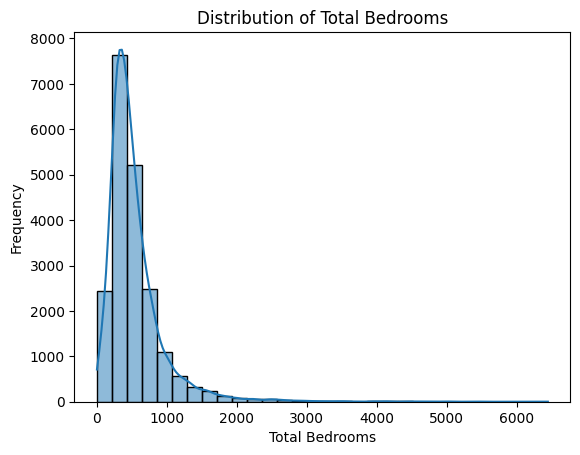

In [8]:
# Show histogram for total_bedrooms
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['total_bedrooms'], bins=30, kde=True)
plt.title('Distribution of Total Bedrooms')
plt.xlabel('Total Bedrooms')
plt.ylabel('Frequency')
plt.show()

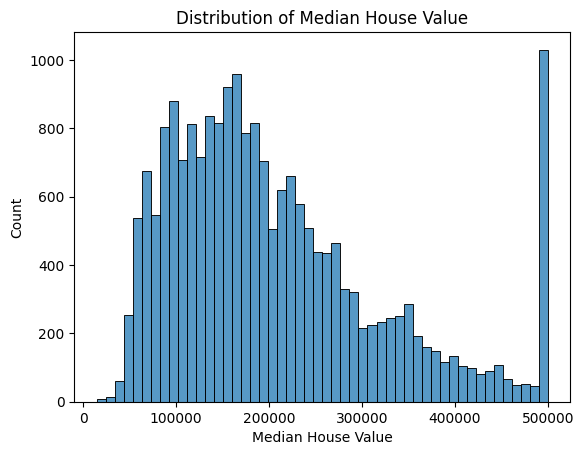

In [7]:
# Show histogram of median_house_value
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df['median_house_value'], bins=50)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Count')
plt.show()

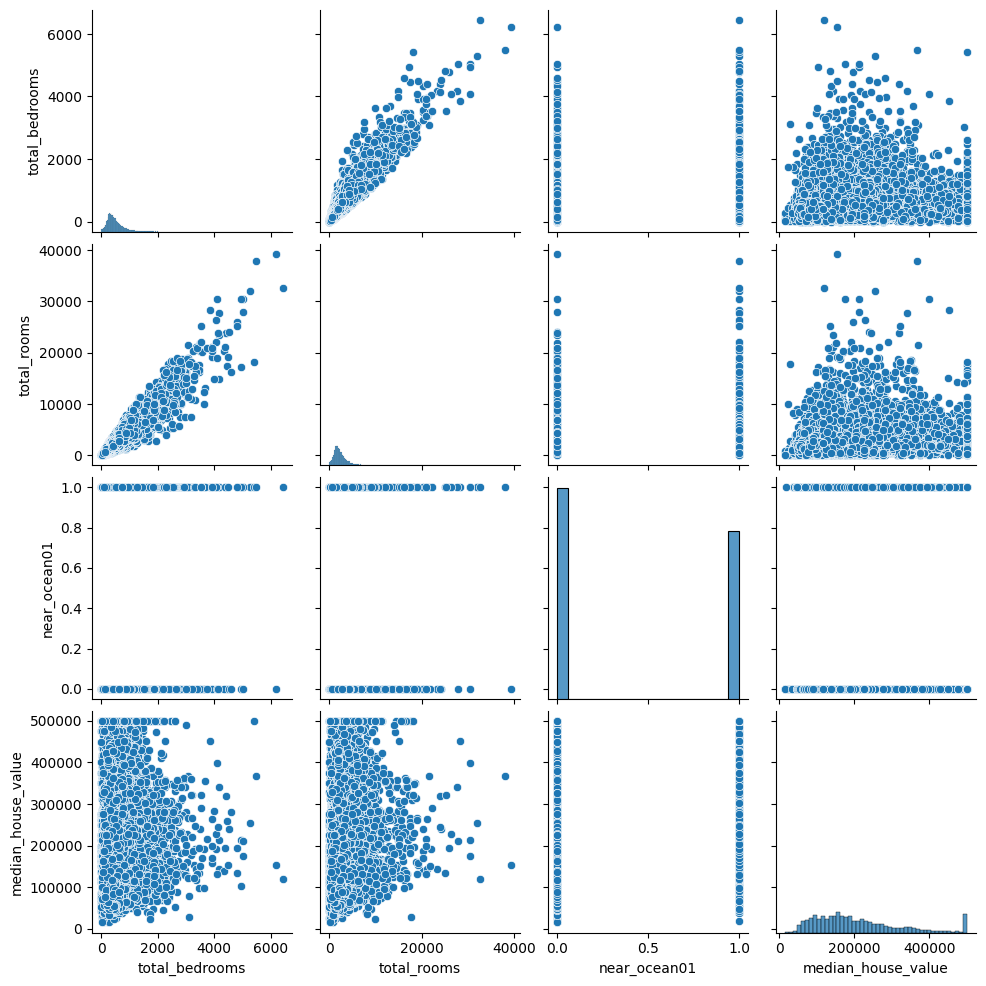

In [9]:
# create a pairplot to show the relationships between the variables
sns.pairplot(df)
plt.show()

## 4. Running the Analysis

We will use statsmodels to run an OLS regression.